## **INFO-61048 (26W) Natural Language Processing:**
# **Project: Ops Knowledge Base AI**

**Author:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 10th, 2026

**GitHub:** [NLP_Ubuntu](https://github.com/virwang/Fanshawe_NLP01.git)

## 1. Executive Summary
**FalconOps** is an advanced IT support tool designed to transform raw, unstructured expert communication logs into a searchable knowledge base. By leveraging **Natural Language Processing (NLP)**, the system assists system administrators in retrieving technical solutions from over 8,000 historical expert records. Unlike traditional keyword-based searches, FalconOps understands the context and intent behind user queries, providing a more reliable and efficient troubleshooting experience.

---

## 2. Problem Statement
Technical support data, particularly from IRC logs or internal chats, is often fragmented and informal. This leads to two major challenges:
* **Information Overload:** It is difficult for junior engineers to find specific solutions within thousands of lines of text.
* **Data Noise:** Informal language and "slang" can make expert advice difficult to interpret or apply in a professional environment.

---

## 3. Technical Architecture
The system is built upon a **Decoupled Architecture**, separating data processing from the user interface to ensure modularity and scalability.



### A. Data Processing Pipeline (NLP_Project)
* **Sentence Embeddings:** Utilizing the `all-MiniLM-L6-v2` Transformer model to convert text instructions into high-dimensional vectors.
* **Vector Storage:** Efficient storage of 8,000+ embeddings using `.npy` format for rapid mathematical comparison.

### B. Logic & Reasoning Engine (brain.py)
* **Semantic Matching:** Uses **Cosine Similarity** to identify the closest expert response to a user's query.
* **Confidence Thresholding:** A critical safety feature that blocks responses with a confidence score below **0.75**, preventing the system from providing irrelevant or incorrect advice.
* **Post-Processing:** A refinement layer that filters informal language and formats the output into a professional advisory tone.

### C. Interface Layer (app.py)
* A streamlined dashboard built with **Streamlit**, providing real-time feedback and a clear escalation path to human experts (Fanshawe Tech Support) when the AI confidence is low.

---

## 4. Key Features
* **Intent Recognition:** Understands technical synonyms (e.g., "modify permissions" vs. "chown").
* **Fail-Safe Mechanism:** Automatically triggers an escalation protocol if no high-confidence solution is found.
* **Optimized Performance:** Uses pre-calculated vector caches to ensure sub-second response times.

---

## 5. Conclusion & Future Work
FalconOps demonstrates the effective application of **Retrieval-Augmented Logic** in a DevOps environment. While the current version focuses on semantic retrieval, future iterations will explore **Style Transfer** models to automatically rewrite informal logs into standardized technical documentation.



## Enviromnent Setup

In [1]:
# NLP & Vector Search
try:
    import datasets, sentence_transformers, faiss
except ImportError:
    !pip install -q datasets sentence-transformers faiss-cpu

## Import Libs

In [2]:
from datasets import load_dataset

import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import faiss

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

import ast
import pickle
import os

# =========================
# Cluster
# =========================
from sklearn.cluster import KMeans
import pandas as pd
import joblib

import warnings
warnings.filterwarnings("ignore")

## Load the dataset

In [3]:
# Load dataset
dataset = load_dataset("sedthh/ubuntu_dialogue_qa",verification_mode="no_checks")
# train dataset
df = pd.DataFrame(dataset['train'])
display(df.head())
print(len(df))

,INSTRUCTION,RESPONSE,SOURCE,METADATA
0,"hi, is there a CLI command to roll back any up...",your recourse is to re-install fresh the older...,ubuntu-dialogue,"{""user_question"": ""edd"", ""user_answer"": ""n8tus..."
1,A LiveCD iso can be burned to a DVD-R and run ...,"I hope so, or the custom DVDs I've done are wo...",ubuntu-dialogue,"{""user_question"": ""usrl"", ""user_answer"": ""Ghos..."
2,"hello, is there a way to adjust gamma settings...",for me i have my nvidia settings manager and i...,ubuntu-dialogue,"{""user_question"": ""nucco_"", ""user_answer"": ""sp..."
3,does ubuntu come with a firewall by default?,no iptables rule is loaded by deault on ubuntu,ubuntu-dialogue,"{""user_question"": ""aeleon"", ""user_answer"": ""er..."
4,Can someone tell me howto get rid of Google Ch...,sudo dpkg -l |grep -i chrom ----> sudo apt-get...,ubuntu-dialogue,"{""user_question"": ""frold"", ""user_answer"": ""shi..."


16173


## Pre-Processing

In this section, we remove the null response from the dataset, and split the dataset into train and test. Then to remove the noise, we get the Questioner and Anserer username data from the METADATA column.

In [4]:
# Remove null
df = df.dropna()

# Split train/test
train_dataset = df.sample(frac=0.8, random_state=42)
test_dataset = df.drop(train_dataset.index)

# Get Users
def extract_answerer(metadata_str):
    try:
        # JSON string to dic
        meta_dict = ast.literal_eval(metadata_str) if isinstance(metadata_str, str) else metadata_str
        q_user = meta_dict.get('user_question', 'unq')
        a_user = meta_dict.get('user_answer', 'una')
        return pd.Series([q_user, a_user])
    except:
        return pd.Series(["unq","una"])


df[['QUESTIONER', 'SOLVER']] = df['METADATA'].apply(extract_answerer)
df['SOLVER'] = df['SOLVER'].str.lower()
df['QUESTIONER'] = df['QUESTIONER'].str.lower()

df = df.drop(columns=['METADATA','SOURCE'])
display(df.tail())
print(len(df))

,INSTRUCTION,RESPONSE,QUESTIONER,SOLVER
16168,is there any GUI irc client besides pidgin ?,xchat,jameela,plong0
16169,"Hello , if I have a log file and i like to see...",you can try watch 'tail /path/to/logfile',zedde,adam7
16170,guys im trying to install itask but when i try...,sudo aptitude install automake autoconf build-...,silvernode,estreyela
16171,is there anyway to recurse with sftp in it's n...,"I believe not, but try lftp instead (it suppor...",psion,seveas
16172,how do i set permissions on /dir so that new s...,-> erUSUL is correct i forgot about those setu...,drx,n8tuser


16173


### Observe the Cumulative response o each solver

Top 30 Solvers account for 19.50% of total data.
Minimum response count in Top 30: 48


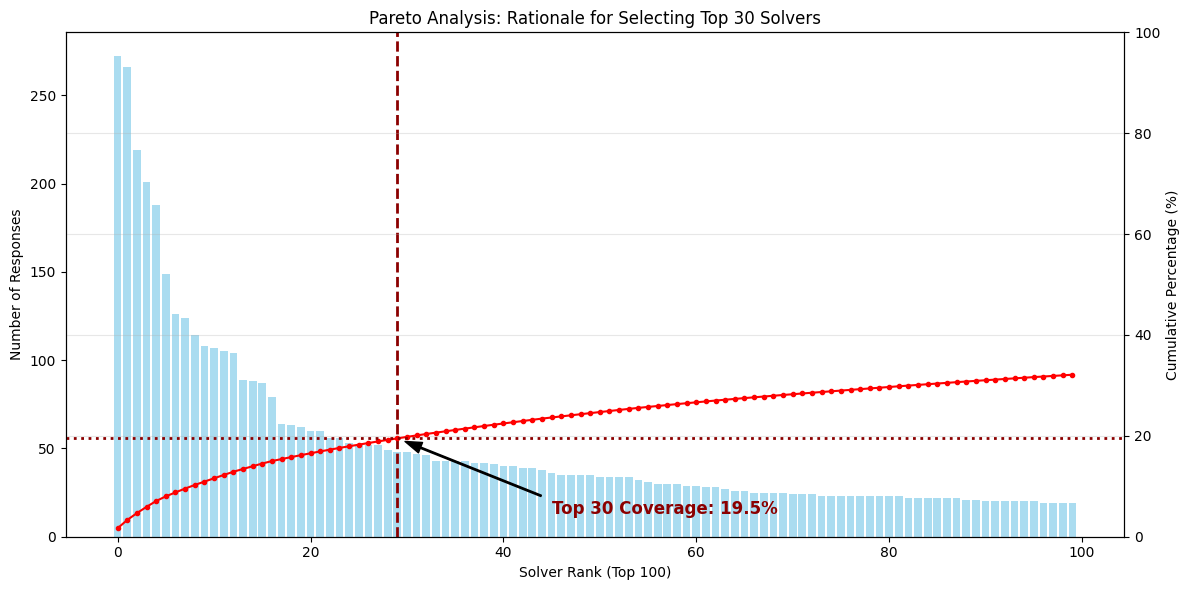

In [5]:
# 1. Prepare data and basic statistics
raw_solver_counts = df['SOLVER'].value_counts()
solver_counts_top30 = raw_solver_counts.head(30)

raw_mean = raw_solver_counts.mean()
raw_median = raw_solver_counts.median()
min_of_top30 = solver_counts_top30.min()

# 2. Calculate Cumulative Coverage (Pareto logic)
total_responses = raw_solver_counts.sum()
cumulative_sum = raw_solver_counts.cumsum()
cumulative_perc = (cumulative_sum / total_responses) * 100

# 3. Get coverage value for the 30th solver (Index 29)
coverage_top30 = cumulative_perc.iloc[29]

# 4. Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Bar chart for individual response counts (Top 100 for context)
ax1.bar(range(100), raw_solver_counts.head(100), color='skyblue', alpha=0.7, label='Response Count')
ax1.set_xlabel('Solver Rank (Top 100)')
ax1.set_ylabel('Number of Responses')

# Secondary Axis: Line chart for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(range(100), cumulative_perc.head(100), color='red', marker='o', markersize=3, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 100)

# Vertical and horizontal lines to mark the Top 30 threshold
ax1.axvline(x=29, color='darkred', linestyle='--', linewidth=2, label='Top 30 Cut-off')
ax2.axhline(y=coverage_top30, color='darkred', linestyle=':', linewidth=2)

# Title and Print Outputs
plt.title('Pareto Analysis: Rationale for Selecting Top 30 Solvers')
print(f"Top 30 Solvers account for {coverage_top30:.2f}% of total data.")
print(f"Minimum response count in Top 30: {min_of_top30}")

# Annotation to highlight the "Elbow Point"
plt.annotate(f'Top 30 Coverage: {coverage_top30:.1f}%',
             xy=(29, coverage_top30), xytext=(45, coverage_top30 - 15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, color='darkred', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Observe top SOLVERS to define Golden medals responser

To get the higer quality datasets, we will only remain the top solvers response.



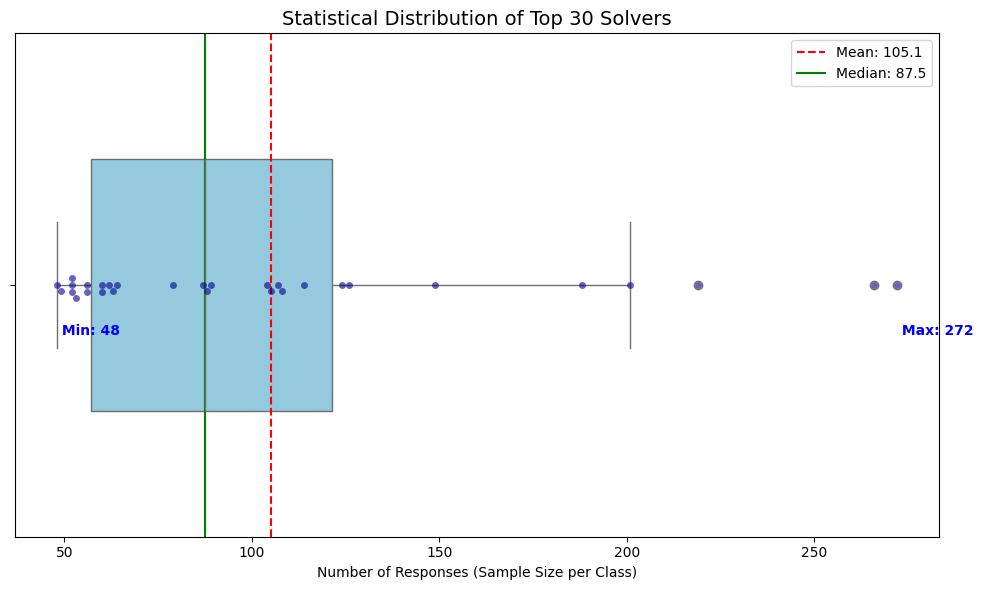

In [6]:
# Create data for plotting
data = solver_counts_top30.values

plt.figure(figsize=(10, 6))

# 1. Create a Box Plot to show the spread
sns.boxplot(x=data, color='skyblue', width=0.5)

# 2. Add a Swarm Plot to show individual data points (the 30 solvers)
sns.swarmplot(x=data, color='darkblue', alpha=0.6)

# 3. Add statistical reference lines and annotations
plt.axvline(x=solver_counts_top30.mean(), color='red', linestyle='--', label=f'Mean: {solver_counts_top30.mean():.1f}')
plt.axvline(x=solver_counts_top30.median(), color='green', linestyle='-', label=f'Median: {solver_counts_top30.median():.1f}')

# 4. Text Annotation for Max and Min
plt.text(solver_counts_top30.max(), 0.1, f' Max: {solver_counts_top30.max()}', color='blue', fontweight='bold')
plt.text(solver_counts_top30.min(), 0.1, f' Min: {solver_counts_top30.min()}', color='blue', fontweight='bold')

plt.title('Statistical Distribution of Top 30 Solvers', fontsize=14)
plt.xlabel('Number of Responses (Sample Size per Class)')
plt.legend()
plt.tight_layout()
plt.show()

### Remain toppers' response

Here we will only remain those toppers' response to make sure the response quality. Some only reply once, so their response might not be accurate.

In [7]:
# Get solvers
top_solvers = solver_counts_top30[solver_counts_top30>=(solver_counts_top30.min())].index

# Remain toppers' response
df_pro = df[df['SOLVER'].isin(top_solvers)].copy()

## Remove short response
df_refined = df_pro[df_pro['RESPONSE'].str.len() > 30].copy()

display(df_refined.head())
print(len(df_refined))

,INSTRUCTION,RESPONSE,QUESTIONER,SOLVER
3,does ubuntu come with a firewall by default?,no iptables rule is loaded by deault on ubuntu,aeleon,erusul
7,is there a way to see if a hard disk has bad b...,"have you considered, however, monitoring your ...",arthurmaciel,ljl
11,"Hi, My Western Digital USB Passport Drive does...",I have one of those too.. it works nicely in u...,steve176,slart
19,hi folks. i am trying to convert screencast I ...,you probably the ffmpeg binaries from medibunt...,jmut,erusul
41,"I made a custom livecd, but what I wanted to d...",change the shell in /etc/passwd,wng-,ikonia


2044


### Get Questions and Anwers list for embending and save it into files or UI

In [8]:
questions = df_refined["INSTRUCTION"].tolist()
answers = df_refined["RESPONSE"].tolist()

print(f"question num:{len(questions)}; answers num:{len(answers)}")

question num:2044; answers num:2044


## Create Model

We have selected SentenceTransformer as our core model due to its superior ability to handle semantic retrieval within the Ubuntu dataset. This model utilizes dense vector embeddings to capture the true intent of user queries. By mapping questions into a high-dimensional vector space, the system performs efficient similarity searches to identify the most relevant archived solutions. This approach ensures high precision in technical troubleshooting while maintaining low computational overhead. Ultimately, SentenceTransformer provides a reliable, scalable, and fact-based foundation, delivering verified community knowledge to users with near-instantaneous response times.

In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Embedding the questions:

To enable efficient semantic retrieval, we performed Text-to-Vector Embedding on the expert knowledge base. By converting natural language into high-dimensional vectors, the system can measure semantic similarity rather than just keyword matching. These vectors are persisted as .npy files to ensure low-latency inference during real-time user interaction.

In [10]:
question_embeddings = model.encode(questions, show_progress_bar=True)
print(question_embeddings)

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

[[ 0.07549541  0.01222624 -0.0249166  ...  0.02297675  0.04964383
   0.01901241]
 [-0.02366473 -0.02739873 -0.04572623 ... -0.05522996 -0.00368845
   0.06834889]
 [-0.00618828 -0.02675087  0.03013167 ...  0.01518089 -0.03224821
   0.06129986]
 ...
 [ 0.00444519  0.00379755 -0.07719884 ...  0.02253566  0.00730566
  -0.09924315]
 [ 0.01187467  0.01458816 -0.01999025 ...  0.02509865 -0.01897436
   0.03461243]
 [ 0.02191286 -0.03294545 -0.02390194 ...  0.06107355  0.06099329
   0.0477547 ]]


## Clustering the Questions

For Frequently asked questions and answers, and catogortize the user query questions

In [11]:
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(question_embeddings) # use current question_embedding

# Save to
df_final = pd.DataFrame({
    'cluster_id': cluster_labels,
    'question': questions,
    'answer': answers
})

display(df_final.head())
print(len(df_final))

,cluster_id,question,answer
0,3,does ubuntu come with a firewall by default?,no iptables rule is loaded by deault on ubuntu
1,2,is there a way to see if a hard disk has bad b...,"have you considered, however, monitoring your ..."
2,2,"Hi, My Western Digital USB Passport Drive does...",I have one of those too.. it works nicely in u...
3,1,hi folks. i am trying to convert screencast I ...,you probably the ffmpeg binaries from medibunt...
4,2,"I made a custom livecd, but what I wanted to d...",change the shell in /etc/passwd


2044


### Evaluate the Cluster result: silhouette_score

In [12]:
score = silhouette_score(question_embeddings, cluster_labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.0245


### Display Clustered Group and contents

In [13]:
from IPython.display import display, Markdown

for cluster_id, group in df_final.groupby('cluster_id'):
    # Show header
    display(Markdown(f"### Cluster {cluster_id} (top 3 rows)"))

    # Show top 5 questions
    display(group[['question']].head(3).reset_index(drop=True))
    print("-" * 80) # split line

### Cluster 0 (top 3 rows)

,question
0,how to set DNS manually? cant find good tutori...
1,"i'm trying to setup upstart, the service works..."
2,When I run $PATH the output ends with 'No such...


--------------------------------------------------------------------------------


### Cluster 1 (top 3 rows)

,question
0,hi folks. i am trying to convert screencast I ...
1,"Hey, me again. I still can't compile alsa-dri..."
2,whats that message when i try to search a apt ...


...

,question
0,does ubuntu come with a firewall by default?
1,hi. new ati driver (8.2) on ati web site! some...
2,hi. could anyone please give me a quick hint o...


--------------------------------------------------------------------------------


### Cluster 4 (top 3 rows)

,question
0,how do I change my login window via text?
1,why does getid open itself as a tab inside a e...
2,Using 8.04 - Update Manager cannot start gtksu...


--------------------------------------------------------------------------------


### TSNE Visualization

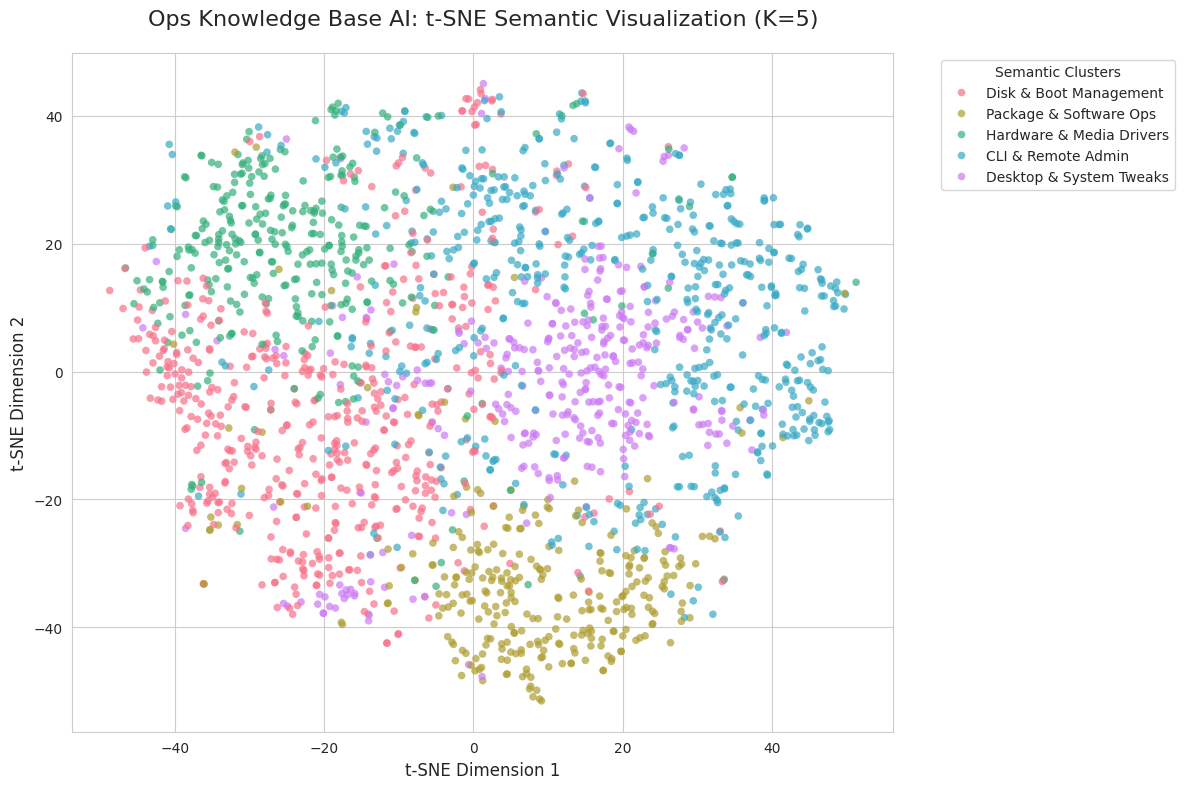

In [14]:
#Define topic map
topic_map = {
    0: "CLI & Remote Admin",
    1: "Hardware & Media Drivers",
    2: "Package & Software Ops",
    3: "Disk & Boot Management",
    4: "Desktop & System Tweaks"
}

#
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

vis_dims = tsne.fit_transform(question_embeddings)

# Graph
df_vis = pd.DataFrame({
    'x': vis_dims[:, 0],
    'y': vis_dims[:, 1],
    'Cluster_ID': cluster_labels,
    'Topic': [topic_map[i] for i in cluster_labels]
})

plt.figure(figsize=(12, 8), dpi=100)
sns.set_style("whitegrid")

# Paint with topic
scatter = sns.scatterplot(
    data=df_vis,
    x='x', y='y',
    hue='Topic',
    palette='husl',
    alpha=0.7,
    edgecolor='none',
    s=30
)

# optimize graph title and label
plt.title("Ops Knowledge Base AI: t-SNE Semantic Visualization (K=5)", fontsize=16, pad=20)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

# Move legend outside the graph avoid covering the pot
plt.legend(title="Semantic Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Saved the cluster for app.py
df_final = pd.DataFrame({
    'question': questions,
    'answer': answers,
    'cluster_id': cluster_labels
})
df_final.to_pickle("expert_data_clustered.pkl")

## Data Serialization for Deployment

We utilized NumPy binary format (.npy) and Pickle (.pkl) to serialize our processed knowledge base. This allows the Streamlit UI to load the pre-computed embeddings and response strings instantly without re-processing the entire dataset (8,000+ records) every time the application starts. This ensures low-latency and high performance for the end-user experience.

In [15]:
print(f"File would be saved in: {os.getcwd()}")

# save vector
np.save('expert_vectors.npy', question_embeddings)
# save df_final answer
with open('expert_answers.pkl', 'wb') as f:
    # pickle.dump(df_final, f)
    # df_final.to_pickle(f)
    pickle.dump(df_final, f)

print("Saved expert answers to 'expert_answers.pkl'")

File would be saved in: /content
Saved expert answers to 'expert_answers.pkl'


## Evaluate the result: Test

The brain.py file should be uploaded to the Colab env in advance

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


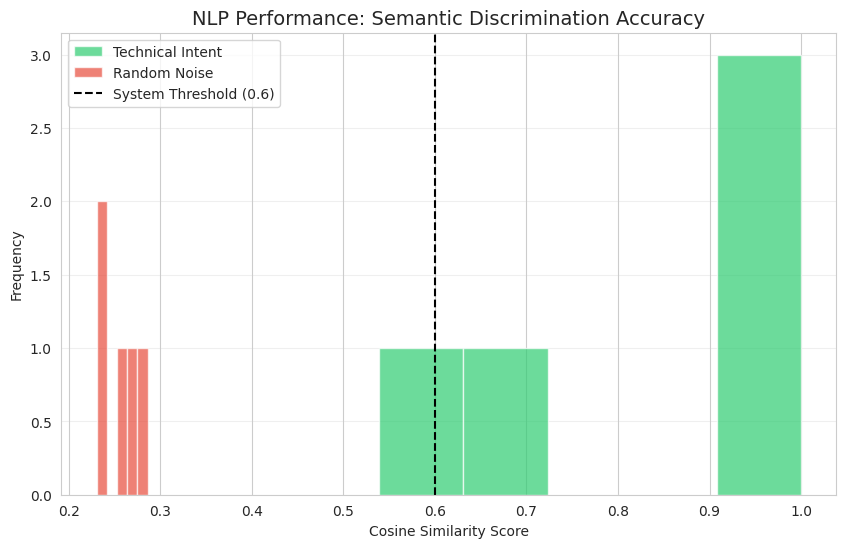

Mean Relevant Score: 0.84
Mean Noise Score: 0.26


In [19]:
from brain import MaintenanceBrain

# 1. Initialize the system
brain = MaintenanceBrain()

# 2. Define Test Samples (Simulated validation)
# Case A: Real technical queries (should have high scores)
test_queries = [
    "how to change file permissions",
    "cannot connect to remote server",
    "low disk space on root partition",
    "reset the admin password",
    "installing new software packages"
]

# Case B: Random noise (should have low scores)
noise_queries = [
    "what is the weather today",
    "i want to eat pizza",
    "tell me a joke",
    "blue sky and birds",
    "how to cook pasta"
]

# 3. Collect Confidence Scores
relevant_scores = [brain.search(q)['confidence'] for q in test_queries]
noise_scores = [brain.search(q)['confidence'] for q in noise_queries]

# 4. Generate Plot
plt.figure(figsize=(10, 6))
plt.hist(relevant_scores, bins=5, alpha=0.7, label='Technical Intent', color='#2ecc71')
plt.hist(noise_scores, bins=5, alpha=0.7, label='Random Noise', color='#e74c3c')
plt.axvline(0.6, color='black', linestyle='--', label='System Threshold (0.6)')

plt.title('NLP Performance: Semantic Discrimination Accuracy', fontsize=14)
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Save for your presentation
plt.savefig('nlp_evaluation.png')
plt.show()

print(f"Mean Relevant Score: {np.mean(relevant_scores):.2f}")
print(f"Mean Noise Score: {np.mean(noise_scores):.2f}")

## Showing the User Interface

#### Set up the environment

In [16]:
!pip install -q streamlit sentence_transformers scikit-learn

!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

--2026-04-14 13:14:24--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-04-14 13:14:24--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab54e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-14T13%3A48%3A57Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b

### Execue the UI file

In [17]:
# 1. kill the old process
!pkill -f streamlit
!pkill -f cloudflared

In [18]:
# 2. Use nohup to ensure Streamlit runs stably in the background
!nohup streamlit run app.py --server.port 8502 &

# 3. Wait 15 seconds for the brain to load the model
import time
print("🧠 Loading expert knowledge base, please wait 15 seconds...")
time.sleep(15)

# 4. restart cloudflared tunnel
print("Building encrypted tunnel...")
!cloudflared tunnel --url http://localhost:8502

nohup: appending output to 'nohup.out'
🧠 Loading expert knowledge base, please wait 15 seconds...
Building encrypted tunnel...
2026-04-14T13:14:42Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-14T13:14:42Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-04-14T13:14:46Z INF +--------------------------------------------------------------------------------------------+
2026-04-14T13:14:46Z INF |  Your quick Tunnel has been created! Visit it a